# Pilot v2 — Full pipeline (first run)

Single notebook: **install → data → train LoRA → generate → metrics → Grad-CAM/LIME → export parent model**.

**After the install cell:** Runtime → **Restart session**, then run from §1 downward (skip install).

## 0. Install (run once, then RESTART SESSION)

In [1]:
import subprocess, sys

pkgs = [
    "diffusers==0.30.0",
    "transformers==4.44.2",
    "accelerate==1.0.1",
    "peft==0.12.0",          # avoids torchao version fight on Kaggle
    "safetensors",
    "torchmetrics[image]",
    "lpips",
    "lime",
    "scikit-image",
    "opencv-python-headless",
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

import numpy as np, torch
print("numpy:", np.__version__)
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available(), "| GPUs:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}:", torch.cuda.get_device_name(i))
print("\n>>> Runtime → Restart session, then continue from §1 (do NOT re-run this cell).")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.9/330.9 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 5.0 MB/s eta 0:00:00
numpy: 2.0.2
torch: 2.10.0+cu128 | CUDA: True | GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4

>>> Runtime → Restart session, then continue from §1 (do NOT re-run this cell).


## 1. Paths & config

In [2]:
import os, random, glob, json, shutil
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
import matplotlib.pyplot as plt

print("numpy", np.__version__, "| torch", torch.__version__)

CSV_CANDIDATES = [
    "/kaggle/input/pilot-meta/prompt_meta.csv",
    "/kaggle/input/datasets/sblab04/pilot-meta/prompt_meta.csv",
]
IMAGE_CANDIDATES = [
    "/kaggle/input/eye-diseases-classification/dataset",
    "/kaggle/input/datasets/fahadhasan93/eye-diseases-classification/dataset",
]

def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(paths)

CSV_PATH = first_existing(CSV_CANDIDATES)
IMAGE_ROOT = first_existing(IMAGE_CANDIDATES)

OUTPUT_DIR = "/kaggle/working/outputs/A_baseline"
GEN_DIR = "/kaggle/working/generated/A_baseline"
RESULTS_DIR = "/kaggle/working/results/A_baseline"
XAI_DIR = os.path.join(RESULTS_DIR, "xai")
for d in [OUTPUT_DIR, GEN_DIR, RESULTS_DIR, XAI_DIR]:
    os.makedirs(d, exist_ok=True)

# --- training knobs ---
RESOLUTION = 512
BATCH_SIZE = 2
GRAD_ACCUM = 4
LR = 1e-4
NUM_EPOCHS = 3              # raise for a real run (e.g. 10–20)
MAX_TRAIN_STEPS = None      # e.g. 100 for a quick smoke test
SEED = 47
LORA_RANK = 8
PRETRAINED = "runwayml/stable-diffusion-v1-5"
NUM_GEN_PER_CLASS = 3
GEN_SEEDS = [47, 133, 478]

print("CSV:", CSV_PATH)
print("Images:", IMAGE_ROOT)

numpy 2.0.2 | torch 2.10.0+cu128
CSV: /kaggle/input/datasets/sblab04/pilot-meta/prompt_meta.csv
Images: /kaggle/input/datasets/fahadhasan93/eye-diseases-classification/dataset


## 2. Dataset

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

df = pd.read_csv(CSV_PATH)
print("columns:", list(df.columns), "| rows:", len(df))

colmap = {}
for c in df.columns:
    cl = c.lower().strip()
    if cl in ("image name", "image_name", "filename", "file_name", "image"):
        colmap[c] = "image_name"
    elif cl in ("class", "label"):
        colmap[c] = "class"
    elif cl in ("prompt", "prompt_tr", "text", "caption"):
        colmap[c] = "prompt"
df = df.rename(columns=colmap)
assert {"image_name", "class", "prompt"}.issubset(df.columns), list(df.columns)

print(df["class"].value_counts())
classes = sorted(df["class"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
class_prompts = {c: str(df[df["class"] == c].iloc[0]["prompt"]) for c in classes}

def resolve_image(name):
    direct = os.path.join(IMAGE_ROOT, str(name))
    if os.path.exists(direct):
        return direct
    for root, _, files in os.walk(IMAGE_ROOT):
        if str(name) in files:
            return os.path.join(root, str(name))
    raise FileNotFoundError(name)

print("path check:", resolve_image(df.iloc[0]["image_name"]))

sd_tfm = T.Compose([
    T.Resize((RESOLUTION, RESOLUTION)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5]),
])

class EyeDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(resolve_image(row["image_name"])).convert("RGB")
        return {
            "image": sd_tfm(img),
            "prompt": str(row["prompt"]),
            "class": str(row["class"]),
        }

idx = np.random.permutation(len(df))
n_val = max(1, int(0.05 * len(df)))
train_ds = EyeDataset(df.iloc[idx[n_val:]])
val_ds = EyeDataset(df.iloc[idx[:n_val]])
print(f"train={len(train_ds)} val={len(val_ds)} classes={classes}")

columns: ['Image name', 'Class', 'prompt_tr'] | rows: 4217
class
diabetic_retinopathy    1098
normal                  1074
cataract                1038
glaucoma                1007
Name: count, dtype: int64
path check: /kaggle/input/datasets/fahadhasan93/eye-diseases-classification/dataset/cataract/0_left.jpg
train=4007 val=210 classes=['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


## 3. Load SD 1.5 + LoRA

VAE + text encoder in fp16 (VRAM). UNet stays **fp32** for stable LoRA training.

In [4]:
from diffusers import AutoencoderKL, DDPMScheduler, UNet2DConditionModel, StableDiffusionPipeline
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weight_dtype = torch.float16

tokenizer = CLIPTokenizer.from_pretrained(PRETRAINED, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(PRETRAINED, subfolder="text_encoder")
vae = AutoencoderKL.from_pretrained(PRETRAINED, subfolder="vae")
unet = UNet2DConditionModel.from_pretrained(PRETRAINED, subfolder="unet")
noise_scheduler = DDPMScheduler.from_pretrained(PRETRAINED, subfolder="scheduler")

text_encoder.requires_grad_(False)
vae.requires_grad_(False)
unet.requires_grad_(False)

text_encoder.to(device, dtype=weight_dtype)
vae.to(device, dtype=weight_dtype)
unet.to(device)  # fp32

unet.add_adapter(LoraConfig(
    r=LORA_RANK, lora_alpha=16, lora_dropout=0.05,
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
))

trainable = [p for p in unet.parameters() if p.requires_grad]
print(f"Trainable params: {sum(p.numel() for p in trainable):,}")
print(f"UNet dtype: {next(unet.parameters()).dtype} | VAE dtype: {next(vae.parameters()).dtype}")

optimizer = torch.optim.AdamW(trainable, lr=LR)
scaler = torch.cuda.amp.GradScaler(enabled=True)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

Trainable params: 1,594,368
UNet dtype: torch.float32 | VAE dtype: torch.float16


/tmp/ipykernel_58/3272951411.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=True)


## 4. One-batch sanity check

In [5]:
sample = train_ds[0]
img = sample["image"].unsqueeze(0).to(device, dtype=weight_dtype)
tok = tokenizer([sample["prompt"]], padding="max_length", truncation=True,
                max_length=tokenizer.model_max_length, return_tensors="pt").to(device)

with torch.no_grad():
    latents = vae.encode(img).latent_dist.sample() * vae.config.scaling_factor
    emb = text_encoder(tok.input_ids)[0]

latents = latents.to(dtype=torch.float32)
emb = emb.to(dtype=torch.float32)
noise = torch.randn_like(latents)
ts = torch.randint(0, noise_scheduler.config.num_train_timesteps, (1,), device=device).long()
noisy = noise_scheduler.add_noise(latents, noise, ts)

pred = unet(noisy, ts, encoder_hidden_states=emb).sample
loss = F.mse_loss(pred.float(), noise.float())
loss.backward()
optimizer.step()
optimizer.zero_grad()
print(f"Sanity OK | latents {tuple(latents.shape)} | loss={loss.item():.4f}")
torch.cuda.empty_cache()

Sanity OK | latents (1, 4, 64, 64) | loss=0.0089


## 5. Train

In [6]:
def collate(batch):
    images = torch.stack([b["image"] for b in batch])
    prompts = [b["prompt"] for b in batch]
    tok = tokenizer(prompts, padding="max_length", truncation=True,
                    max_length=tokenizer.model_max_length, return_tensors="pt")
    return {"image": images, "input_ids": tok.input_ids}

loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=2, collate_fn=collate, drop_last=True)

unet.train()
global_step = 0
epoch_logs = []

for epoch in range(1, NUM_EPOCHS + 1):
    running, n = 0.0, 0
    optimizer.zero_grad()
    for step, batch in enumerate(loader):
        images = batch["image"].to(device, dtype=weight_dtype)
        input_ids = batch["input_ids"].to(device)

        with torch.no_grad():
            latents = vae.encode(images).latent_dist.sample() * vae.config.scaling_factor
            emb = text_encoder(input_ids)[0]

        latents = latents.to(dtype=torch.float32)
        emb = emb.to(dtype=torch.float32)
        noise = torch.randn_like(latents)
        bsz = latents.shape[0]
        ts = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=device).long()
        noisy = noise_scheduler.add_noise(latents, noise, ts)

        with torch.autocast("cuda", dtype=torch.float16):
            pred = unet(noisy, ts, encoder_hidden_states=emb).sample
            loss = F.mse_loss(pred.float(), noise.float()) / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainable, 1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            global_step += 1

        running += loss.item() * GRAD_ACCUM
        n += 1
        if step % 20 == 0:
            print(f"epoch {epoch}/{NUM_EPOCHS} step {step}/{len(loader)} loss={loss.item()*GRAD_ACCUM:.4f}")

        if MAX_TRAIN_STEPS is not None and global_step >= MAX_TRAIN_STEPS:
            break

    avg = running / max(1, n)
    epoch_logs.append({"epoch": epoch, "avg_train_loss": avg, "global_step": global_step})
    print(f"=== epoch {epoch} avg_loss={avg:.4f} step={global_step} ===")
    ckpt = os.path.join(OUTPUT_DIR, f"lora_epoch{epoch}")
    unet.save_pretrained(ckpt)
    print("saved", ckpt)

    if MAX_TRAIN_STEPS is not None and global_step >= MAX_TRAIN_STEPS:
        break

pd.DataFrame(epoch_logs).to_csv(os.path.join(RESULTS_DIR, "epoch_metrics.csv"), index=False)
print("Training finished.")

epoch 1/3 step 0/2003 loss=0.0240
epoch 1/3 step 20/2003 loss=0.1044
epoch 1/3 step 40/2003 loss=0.1405
epoch 1/3 step 60/2003 loss=0.0145
epoch 1/3 step 80/2003 loss=0.0125
epoch 1/3 step 100/2003 loss=0.2915
epoch 1/3 step 120/2003 loss=0.0642
epoch 1/3 step 140/2003 loss=0.0049
epoch 1/3 step 160/2003 loss=0.1660
epoch 1/3 step 180/2003 loss=0.0460
epoch 1/3 step 200/2003 loss=0.1414
epoch 1/3 step 220/2003 loss=0.0048
epoch 1/3 step 240/2003 loss=0.0084
epoch 1/3 step 260/2003 loss=0.2371
epoch 1/3 step 280/2003 loss=0.0354
epoch 1/3 step 300/2003 loss=0.0354
epoch 1/3 step 320/2003 loss=0.0469
epoch 1/3 step 340/2003 loss=0.0669
epoch 1/3 step 360/2003 loss=0.0031
epoch 1/3 step 380/2003 loss=0.0474
epoch 1/3 step 400/2003 loss=0.0444
epoch 1/3 step 420/2003 loss=0.0401
epoch 1/3 step 440/2003 loss=0.2788
epoch 1/3 step 460/2003 loss=0.3630
epoch 1/3 step 480/2003 loss=0.0286
epoch 1/3 step 500/2003 loss=0.0783
epoch 1/3 step 520/2003 loss=0.3816
epoch 1/3 step 540/2003 loss=0.125

## 6. Generate class-wise samples

  cataract: high quality fundus photograph of an eye with cataract, cloudy lens, reduced clarity, medi...
  diabetic_retinopathy: high quality fundus photograph of an eye with diabetic retinopathy, microaneurysms, hemorr...
  glaucoma: high quality fundus photograph of an eye with glaucoma, optic disc cupping, increased cup-...
  normal: high quality fundus photograph of a healthy normal eye, clear optic disc, healthy retinal ...


  0%|          | 0/30 [00:00<?, ?it/s]

saved /kaggle/working/generated/A_baseline/cataract/sample_00_seed47.png


  0%|          | 0/30 [00:00<?, ?it/s]

saved /kaggle/working/generated/A_baseline/cataract/sample_01_seed133.png


...

saved /kaggle/working/generated/A_baseline/normal/sample_00_seed47.png


  0%|          | 0/30 [00:00<?, ?it/s]

saved /kaggle/working/generated/A_baseline/normal/sample_01_seed133.png


  0%|          | 0/30 [00:00<?, ?it/s]

saved /kaggle/working/generated/A_baseline/normal/sample_02_seed478.png

Done -> /kaggle/working/generated/A_baseline


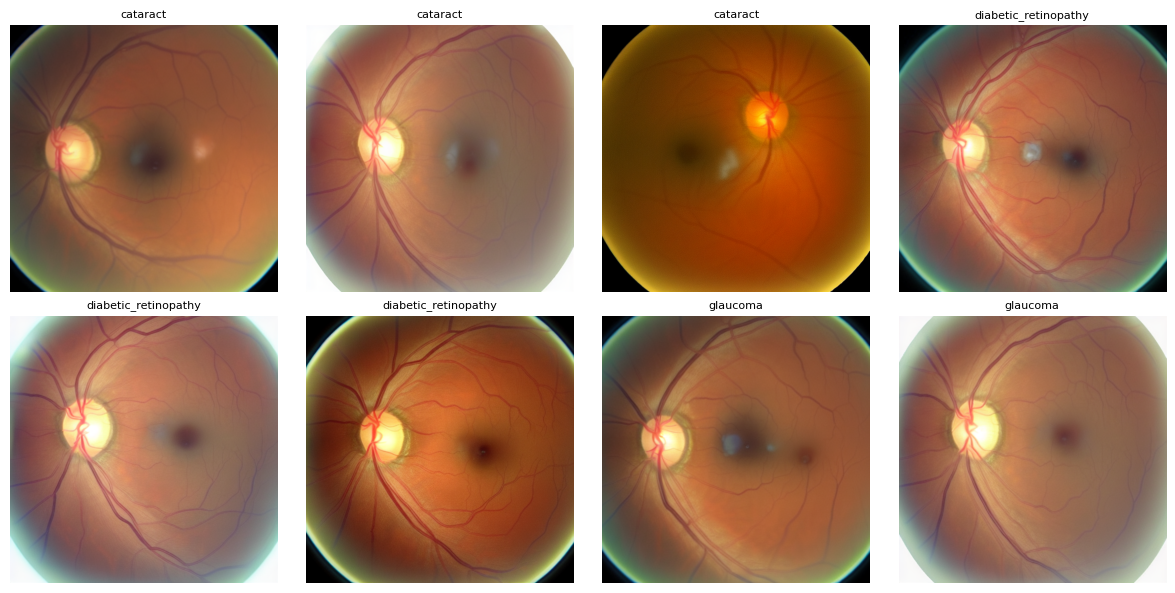

In [7]:
unet.eval()
unet.to(device, dtype=torch.float16)

pipe = StableDiffusionPipeline(
    vae=vae,
    text_encoder=text_encoder,
    tokenizer=tokenizer,
    unet=unet,
    scheduler=noise_scheduler,
    safety_checker=None,
    feature_extractor=None,
    requires_safety_checker=False,
).to(device)

for c, p in class_prompts.items():
    print(f"  {c}: {p[:90]}...")

gen_rows = []
for class_name, prompt in class_prompts.items():
    out_cls = os.path.join(GEN_DIR, class_name)
    os.makedirs(out_cls, exist_ok=True)
    for i, seed in enumerate(GEN_SEEDS[:NUM_GEN_PER_CLASS]):
        g = torch.Generator(device=device).manual_seed(seed)
        with torch.autocast("cuda", dtype=torch.float16):
            img = pipe(prompt, num_inference_steps=30, guidance_scale=7.5, generator=g).images[0]
        path = os.path.join(out_cls, f"sample_{i:02d}_seed{seed}.png")
        img.save(path)
        gen_rows.append({"class": class_name, "seed": seed, "path": path, "prompt": prompt})
        print("saved", path)

pd.DataFrame(gen_rows).to_csv(os.path.join(RESULTS_DIR, "generation_log.csv"), index=False)
print("\nDone ->", GEN_DIR)

# quick preview
paths = sorted(glob.glob(os.path.join(GEN_DIR, "*", "*.png")))[:8]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, p in zip(axes.flatten(), paths):
    ax.imshow(Image.open(p))
    ax.set_title(os.path.basename(os.path.dirname(p))[:24], fontsize=8)
    ax.axis("off")
for ax in axes.flatten()[len(paths):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "gen_preview.png"), dpi=120)
plt.show()

## 7. Metrics — inventory, FID/KID, LPIPS, CLIP

In [8]:
def list_images(root, exts=(".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
    out = []
    for r, _, files in os.walk(root):
        for f in files:
            if f.lower().endswith(exts):
                out.append(os.path.join(r, f))
    return sorted(out)

rows = []
for c in classes:
    real = [p for p in list_images(IMAGE_ROOT) if c.lower() in p.lower()]
    gen = sorted(glob.glob(os.path.join(GEN_DIR, c, "*.png")))
    rows.append({"class": c, "n_real_approx": len(real), "n_generated": len(gen)})
inv = pd.DataFrame(rows)
inv.loc[len(inv)] = {
    "class": "OVERALL",
    "n_real_approx": inv["n_real_approx"].sum(),
    "n_generated": inv["n_generated"].sum(),
}
inv.to_csv(os.path.join(RESULTS_DIR, "inventory.csv"), index=False)
print(inv.to_string(index=False))

               class  n_real_approx  n_generated
            cataract           1038            3
diabetic_retinopathy           1098            3
            glaucoma           1007            3
              normal           1074            3
             OVERALL           4217           12


In [9]:
def load_uint8_batch(paths, size=299, max_n=100):
    tfm = T.Compose([T.Resize((size, size)), T.ToTensor()])
    paths = paths[:max_n]
    tensors = []
    for p in paths:
        try:
            tensors.append(tfm(Image.open(p).convert("RGB")))
        except Exception:
            continue
    if not tensors:
        return None
    return (torch.stack(tensors) * 255).to(torch.uint8)

def compute_fid_kid(real_paths, fake_paths):
    try:
        from torchmetrics.image.fid import FrechetInceptionDistance
        from torchmetrics.image.kid import KernelInceptionDistance
    except ImportError as e:
        print("torchmetrics missing:", e)
        return {}
    real = load_uint8_batch(real_paths)
    fake = load_uint8_batch(fake_paths)
    if real is None or fake is None or len(real) < 2 or len(fake) < 2:
        return {"fid": None, "kid": None,
                "n_real": 0 if real is None else len(real),
                "n_fake": 0 if fake is None else len(fake)}
    out = {"n_real": len(real), "n_fake": len(fake)}
    try:
        fid = FrechetInceptionDistance(normalize=False)
        fid.update(real, real=True)
        fid.update(fake, real=False)
        out["fid"] = float(fid.compute())
    except Exception as e:
        print("FID failed:", e); out["fid"] = None
    try:
        n_sub = min(len(real), len(fake), 50)
        if n_sub >= 2:
            kid = KernelInceptionDistance(normalize=False, subset_size=n_sub)
            kid.update(real, real=True)
            kid.update(fake, real=False)
            km, _ = kid.compute()
            out["kid"] = float(km)
        else:
            out["kid"] = None
    except Exception as e:
        print("KID failed:", e); out["kid"] = None
    return out

all_real, all_fake = [], []
fid_rows = []
for c in classes:
    real_paths = [p for p in list_images(IMAGE_ROOT) if c.lower() in p.lower()]
    if not real_paths:
        real_paths = []
        for name in df[df["class"] == c]["image_name"].astype(str).tolist()[:80]:
            try:
                real_paths.append(resolve_image(name))
            except FileNotFoundError:
                pass
    fake_paths = sorted(glob.glob(os.path.join(GEN_DIR, c, "*.png")))
    all_real.extend(real_paths[:80])
    all_fake.extend(fake_paths)
    m = compute_fid_kid(real_paths, fake_paths)
    fid_rows.append({"class": c, **m})
    print(f"{c}: FID={m.get('fid')} KID={m.get('kid')}")

m_all = compute_fid_kid(all_real, all_fake)
fid_rows.append({"class": "OVERALL", **m_all})
print(f"OVERALL: FID={m_all.get('fid')} KID={m_all.get('kid')}")
fid_df = pd.DataFrame(fid_rows)
fid_df.to_csv(os.path.join(RESULTS_DIR, "fid_kid.csv"), index=False)
fid_df

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 234MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


cataract: FID=249.12965393066406 KID=0.18213146924972534
diabetic_retinopathy: FID=196.2683563232422 KID=0.1265886276960373
glaucoma: FID=247.21621704101562 KID=0.1819923371076584
normal: FID=226.45542907714844 KID=0.1897483468055725
OVERALL: FID=211.669677734375 KID=0.1879827380180359


,class,n_real,n_fake,fid,kid
0,cataract,100,3,249.129654,0.182131
1,diabetic_retinopathy,100,3,196.268356,0.126589
2,glaucoma,100,3,247.216217,0.181992
3,normal,100,3,226.455429,0.189748
4,OVERALL,100,12,211.669678,0.187983


In [10]:
def compute_lpips(real_paths, fake_paths, n_pairs=20, seed=47):
    try:
        import lpips
    except ImportError as e:
        print("lpips missing:", e)
        return None
    if not real_paths or not fake_paths:
        return None
    loss_fn = lpips.LPIPS(net="alex").eval()
    if torch.cuda.is_available():
        loss_fn = loss_fn.cuda()
    tfm = T.Compose([T.Resize((256, 256)), T.ToTensor()])
    rng = random.Random(seed)
    scores = []
    for _ in range(min(n_pairs, len(fake_paths))):
        r = tfm(Image.open(rng.choice(real_paths)).convert("RGB")) * 2 - 1
        f = tfm(Image.open(rng.choice(fake_paths)).convert("RGB")) * 2 - 1
        r, f = r.unsqueeze(0), f.unsqueeze(0)
        if torch.cuda.is_available():
            r, f = r.cuda(), f.cuda()
        with torch.no_grad():
            scores.append(float(loss_fn(r, f).item()))
    return float(np.mean(scores)) if scores else None

lpips_rows = []
for c in classes:
    real_paths = [p for p in list_images(IMAGE_ROOT) if c.lower() in p.lower()]
    fake_paths = sorted(glob.glob(os.path.join(GEN_DIR, c, "*.png")))
    score = compute_lpips(real_paths, fake_paths)
    lpips_rows.append({"class": c, "lpips": score, "n_fake": len(fake_paths)})
    print(f"{c}: LPIPS={score}")
lpips_df = pd.DataFrame(lpips_rows)
lpips_df.to_csv(os.path.join(RESULTS_DIR, "lpips.csv"), index=False)
lpips_df

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 194MB/s]  


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
cataract: LPIPS=0.6360220114390055
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
diabetic_retinopathy: LPIPS=0.5862834850947062
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
glaucoma: LPIPS=0.6524725357691447
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
normal: LPIPS=0.6456887722015381


,class,lpips,n_fake
0,cataract,0.636022,3
1,diabetic_retinopathy,0.586283,3
2,glaucoma,0.652473,3
3,normal,0.645689,3


In [11]:
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
clip_proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

clip_rows = []
for c in classes:
    prompt = class_prompts[c]
    paths = sorted(glob.glob(os.path.join(GEN_DIR, c, "*.png")))
    scores = []
    for p in paths:
        img = Image.open(p).convert("RGB")
        inputs = clip_proc(text=[prompt], images=img, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = clip_model(**inputs)
            s = F.cosine_similarity(out.image_embeds, out.text_embeds).item()
        scores.append(s)
        clip_rows.append({"class": c, "image": os.path.basename(p), "clip_score": s})
    print(f"{c}: mean CLIP={np.mean(scores) if scores else float('nan'):.4f}")

clip_df = pd.DataFrame(clip_rows)
clip_df.to_csv(os.path.join(RESULTS_DIR, "clip_scores.csv"), index=False)
clip_summary = clip_df.groupby("class")["clip_score"].agg(["mean", "std", "count"]).reset_index()
clip_summary.to_csv(os.path.join(RESULTS_DIR, "clip_scores_summary.csv"), index=False)
clip_summary

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


cataract: mean CLIP=0.3061
diabetic_retinopathy: mean CLIP=0.3173
glaucoma: mean CLIP=0.3215
normal: mean CLIP=0.3181


,class,mean,std,count
0,cataract,0.306149,0.008883,3
1,diabetic_retinopathy,0.317325,0.000612,3
2,glaucoma,0.321492,0.006605,3
3,normal,0.318051,0.010807,3


In [12]:
master = inv.copy()
master = master.merge(fid_df, on="class", how="left")
master = master.merge(lpips_df[["class", "lpips"]], on="class", how="left")
master = master.merge(
    clip_summary.rename(columns={"mean": "clip_mean", "std": "clip_std", "count": "clip_n"}),
    on="class", how="left",
)
master.to_csv(os.path.join(RESULTS_DIR, "master_metrics.csv"), index=False)
print(master.to_string(index=False))

checks = [("has_generations", int(master.loc[master["class"]=="OVERALL", "n_generated"].values[0]) > 0)]
for c in classes:
    checks.append((f"class_{c}_has_samples",
                   int(master.loc[master["class"]==c, "n_generated"].values[0]) > 0))
print("\n--- sanity ---")
for name, ok in checks:
    print(f"[{'PASS' if ok else 'FAIL'}] {name}")
with open(os.path.join(RESULTS_DIR, "sanity_checks.json"), "w") as f:
    json.dump({k: bool(v) for k, v in checks}, f, indent=2)

               class  n_real_approx  n_generated  n_real  n_fake        fid      kid    lpips  clip_mean  clip_std  clip_n
            cataract           1038            3     100       3 249.129654 0.182131 0.636022   0.306149  0.008883     3.0
diabetic_retinopathy           1098            3     100       3 196.268356 0.126589 0.586283   0.317325  0.000612     3.0
            glaucoma           1007            3     100       3 247.216217 0.181992 0.652473   0.321492  0.006605     3.0
              normal           1074            3     100       3 226.455429 0.189748 0.645689   0.318051  0.010807     3.0
             OVERALL           4217           12     100      12 211.669678 0.187983      NaN        NaN       NaN     NaN

--- sanity ---
[PASS] has_generations
[PASS] class_cataract_has_samples
[PASS] class_diabetic_retinopathy_has_samples
[PASS] class_glaucoma_has_samples
[PASS] class_normal_has_samples


## 8. Real vs generated visual grid

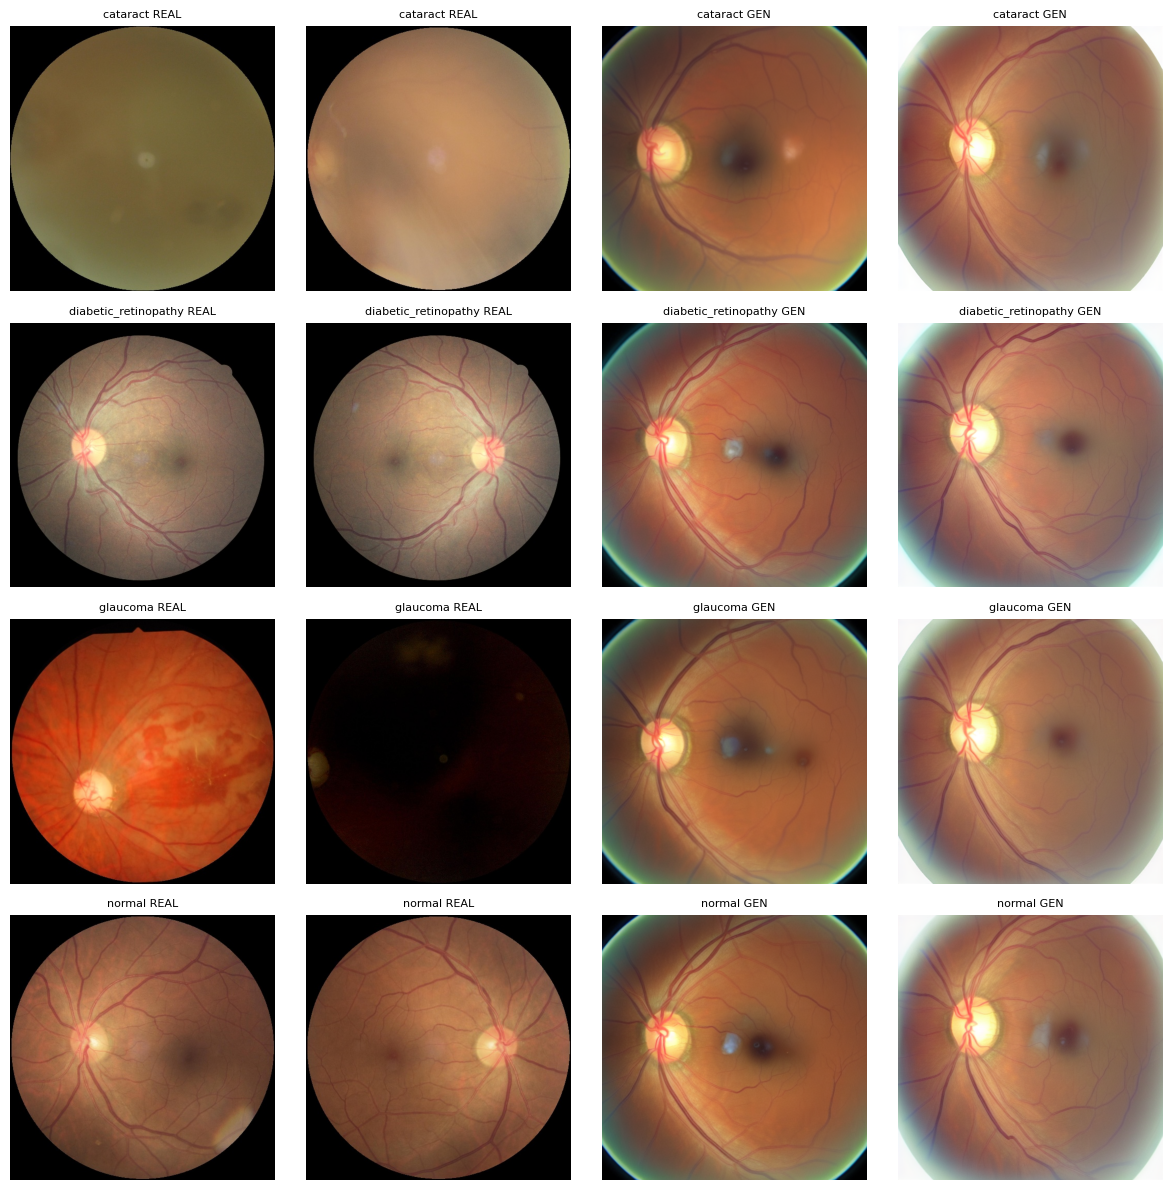

In [13]:
def pick_real(c, k=2):
    paths = [p for p in list_images(IMAGE_ROOT) if c.lower() in p.lower()]
    if not paths:
        paths = []
        for name in df[df["class"] == c]["image_name"].astype(str).head(20):
            try:
                paths.append(resolve_image(name))
            except FileNotFoundError:
                pass
    return paths[:k]

fig, axes = plt.subplots(len(classes), 4, figsize=(12, 3 * len(classes)))
if len(classes) == 1:
    axes = np.array([axes])
for i, c in enumerate(classes):
    reals, fakes = pick_real(c, 2), sorted(glob.glob(os.path.join(GEN_DIR, c, "*.png")))[:2]
    for j, p in enumerate(reals):
        axes[i, j].imshow(Image.open(p).convert("RGB")); axes[i, j].set_title(f"{c} REAL", fontsize=8); axes[i, j].axis("off")
    for j, p in enumerate(fakes):
        axes[i, 2+j].imshow(Image.open(p).convert("RGB")); axes[i, 2+j].set_title(f"{c} GEN", fontsize=8); axes[i, 2+j].axis("off")
    for j in range(len(reals), 2):
        axes[i, j].axis("off")
    for j in range(len(fakes), 2):
        axes[i, 2+j].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "real_vs_gen_grid.png"), dpi=120)
plt.show()

## 9. Explainability — Grad-CAM + LIME (where lesions appear)

Train a small **probe** classifier on real labels, then explain **generated** images:
- **Grad-CAM** → pixels that raise the disease score
- **LIME** → superpixels that support the class

In [14]:
probe_tfm = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class ProbeDS(Dataset):
    def __init__(self, dataframe):
        self.rows = []
        for _, row in dataframe.iterrows():
            try:
                p = resolve_image(row["image_name"])
                self.rows.append((p, class_to_idx[str(row["class"])]))
            except FileNotFoundError:
                pass
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, i):
        p, y = self.rows[i]
        return probe_tfm(Image.open(p).convert("RGB")), y

rng = np.random.RandomState(47)
perm = rng.permutation(len(df))
n_val = max(1, int(0.1 * len(df)))
train_loader = DataLoader(ProbeDS(df.iloc[perm[n_val:]]), batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(ProbeDS(df.iloc[perm[:n_val]]), batch_size=16, shuffle=False, num_workers=2)
print(f"probe train={len(train_loader.dataset)} val={len(val_loader.dataset)}")

probe = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
probe.fc = nn.Linear(probe.fc.in_features, len(classes))
probe = probe.to(device)
opt = torch.optim.AdamW(probe.parameters(), lr=1e-4)
crit = nn.CrossEntropyLoss()

PROBE_EPOCHS = 3
for ep in range(1, PROBE_EPOCHS + 1):
    probe.train()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        logits = probe(x)
        loss = crit(logits, y)
        loss.backward()
        opt.step()
        loss_sum += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    probe.eval()
    vtot, vcor = 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            vcor += (probe(x).argmax(1) == y).sum().item()
            vtot += x.size(0)
    print(f"probe epoch {ep}: loss={loss_sum/max(1,total):.4f} acc={correct/max(1,total):.3f} val_acc={vcor/max(1,vtot):.3f}")

probe.eval()
torch.save(probe.state_dict(), os.path.join(RESULTS_DIR, "probe_resnet18.pt"))
print("probe saved")

probe train=3796 val=421
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PAR

probe epoch 1: loss=0.3596 acc=0.865 val_acc=0.900


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

probe epoch 2: loss=0.1834 acc=0.932 val_acc=0.910


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

probe epoch 3: loss=0.1157 acc=0.962 val_acc=0.917
probe saved


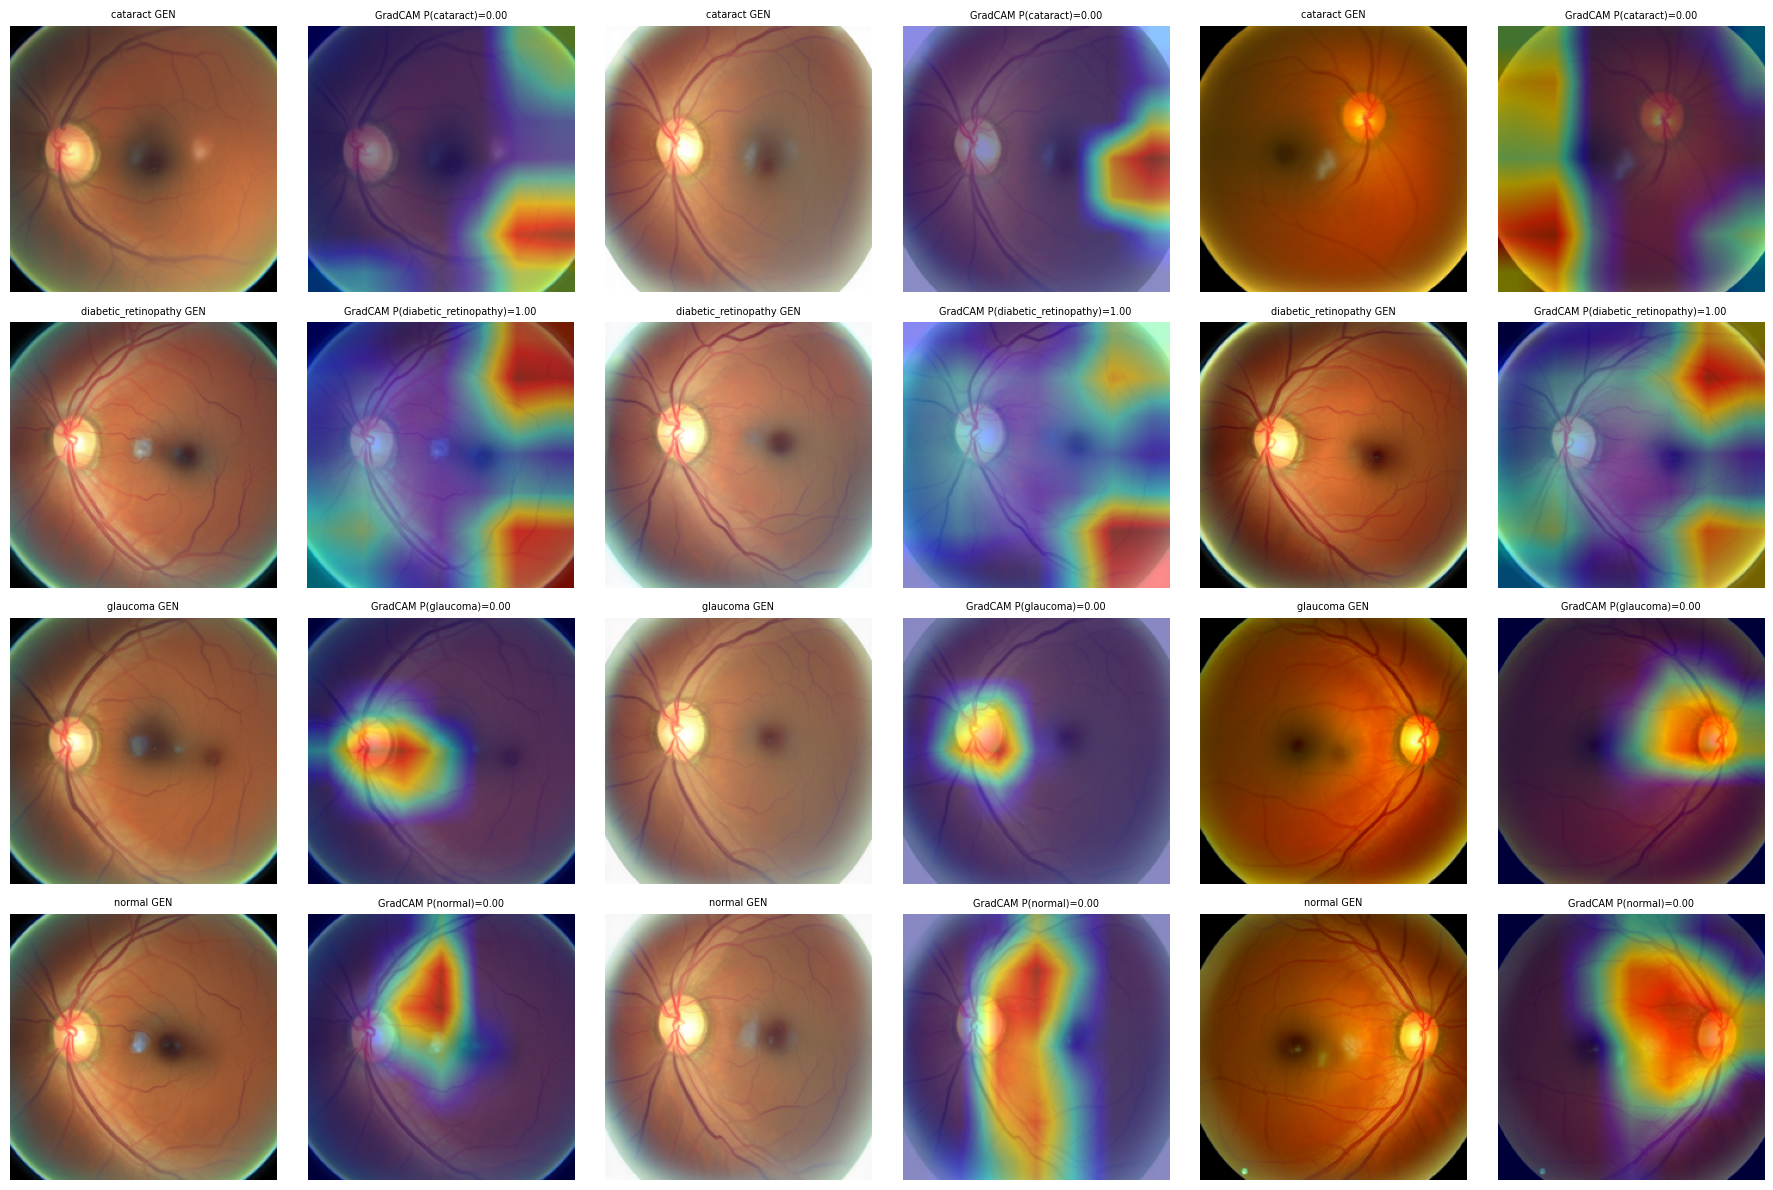

Grad-CAM done -> /kaggle/working/results/A_baseline/xai


In [15]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._fwd)
        target_layer.register_full_backward_hook(self._bwd)
    def _fwd(self, module, inp, out):
        self.activations = out.detach()
    def _bwd(self, module, gin, gout):
        self.gradients = gout[0].detach()
    def __call__(self, x, class_idx=None):
        self.model.zero_grad()
        logits = self.model(x)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())
        logits[0, class_idx].backward(retain_graph=True)
        weights = self.gradients[0].mean(dim=(1, 2))
        cam = F.relu((weights[:, None, None] * self.activations[0]).sum(0))
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy(), class_idx, logits.softmax(1)[0].detach().cpu().numpy()

def overlay_cam(pil_img, cam, alpha=0.45):
    import cv2
    img = np.array(pil_img.resize((224, 224))).astype(np.float32) / 255.0
    heatmap = cv2.resize(cam, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)[:, :, ::-1].astype(np.float32) / 255.0
    out = np.clip((1 - alpha) * img + alpha * heatmap, 0, 1)
    return Image.fromarray((out * 255).astype(np.uint8))

cam_extractor = GradCAM(probe, probe.layer4)
n_per_class = 3
gradcam_rows = []

fig, axes = plt.subplots(len(classes), n_per_class * 2, figsize=(3 * n_per_class * 2, 3 * len(classes)))
if len(classes) == 1:
    axes = np.array([axes])

for i, c in enumerate(classes):
    paths = sorted(glob.glob(os.path.join(GEN_DIR, c, "*.png")))[:n_per_class]
    target_idx = class_to_idx[c]
    for j, p in enumerate(paths):
        pil = Image.open(p).convert("RGB")
        x = probe_tfm(pil).unsqueeze(0).to(device)
        cam, pred_idx, probs = cam_extractor(x, class_idx=target_idx)
        overlay = overlay_cam(pil, cam)
        axes[i, 2*j].imshow(pil.resize((224, 224))); axes[i, 2*j].set_title(f"{c} GEN", fontsize=7); axes[i, 2*j].axis("off")
        axes[i, 2*j+1].imshow(overlay)
        axes[i, 2*j+1].set_title(f"GradCAM P({c})={probs[target_idx]:.2f}", fontsize=7)
        axes[i, 2*j+1].axis("off")
        stem = os.path.splitext(os.path.basename(p))[0]
        overlay.save(os.path.join(XAI_DIR, f"gradcam_{c}_{stem}.png"))
        gradcam_rows.append({
            "class": c, "image": os.path.basename(p),
            "pred_class": idx_to_class[pred_idx],
            "prob_target": float(probs[target_idx]),
            "prob_pred": float(probs[pred_idx]),
        })
    for j in range(len(paths), n_per_class):
        axes[i, 2*j].axis("off"); axes[i, 2*j+1].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(XAI_DIR, "gradcam_grid.png"), dpi=120)
plt.show()
pd.DataFrame(gradcam_rows).to_csv(os.path.join(XAI_DIR, "gradcam_scores.csv"), index=False)
print("Grad-CAM done ->", XAI_DIR)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

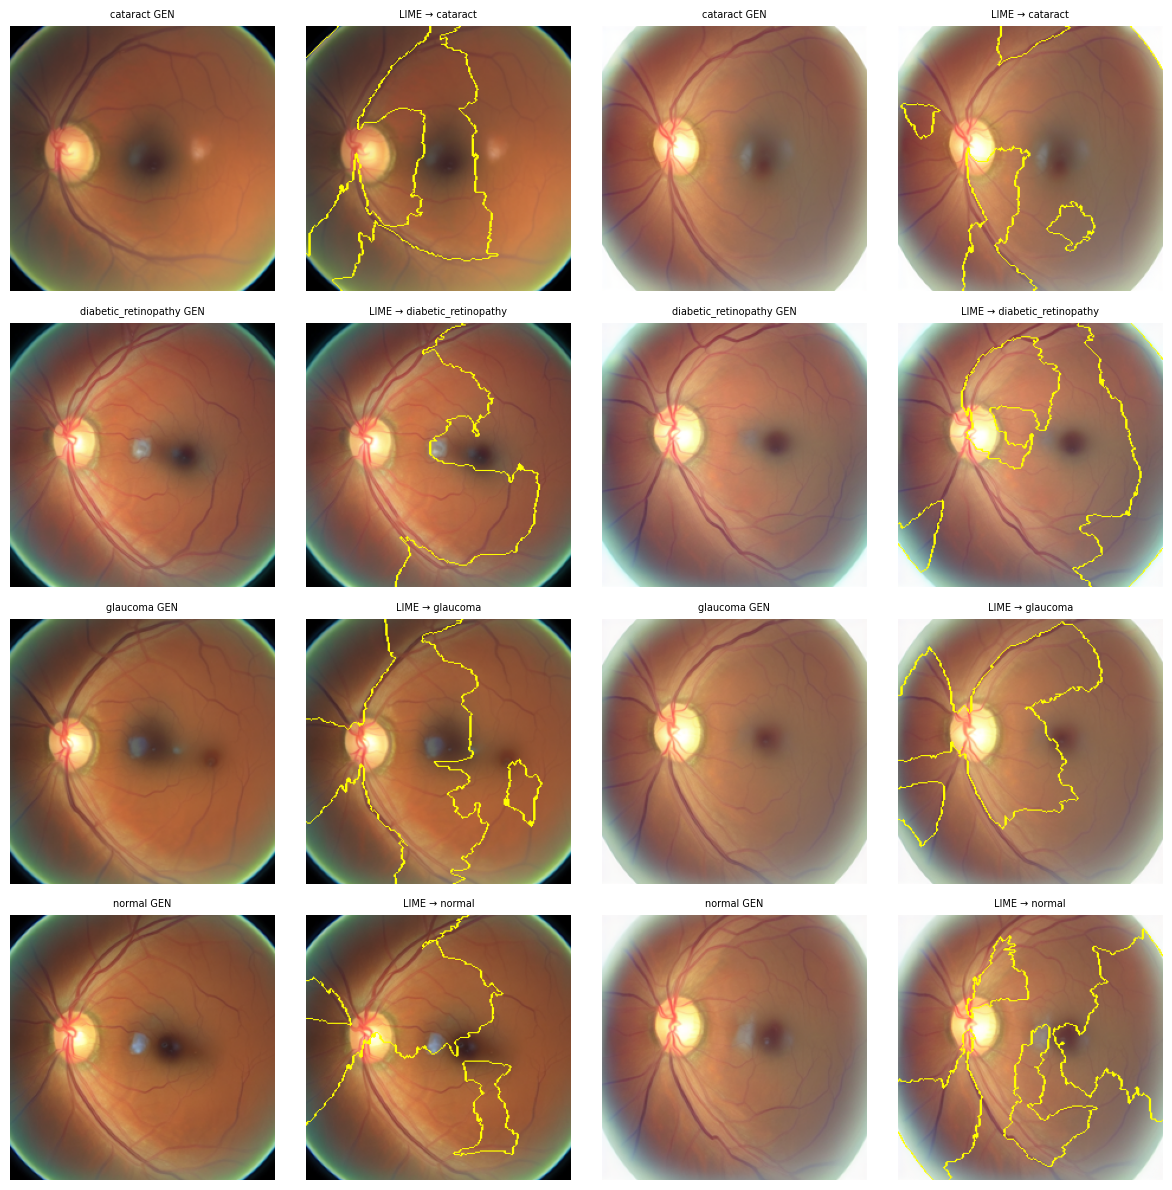

LIME done -> /kaggle/working/results/A_baseline/xai


In [16]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

def predict_proba_batch(images_hwc_float):
    probe.eval()
    tensors = []
    for arr in images_hwc_float:
        pil = Image.fromarray((np.clip(arr, 0, 1) * 255).astype(np.uint8))
        tensors.append(probe_tfm(pil))
    x = torch.stack(tensors).to(device)
    with torch.no_grad():
        return probe(x).softmax(1).cpu().numpy()

explainer = lime_image.LimeImageExplainer()
n_lime = 2
lime_rows = []

fig, axes = plt.subplots(len(classes), n_lime * 2, figsize=(3 * n_lime * 2, 3 * len(classes)))
if len(classes) == 1:
    axes = np.array([axes])

for i, c in enumerate(classes):
    paths = sorted(glob.glob(os.path.join(GEN_DIR, c, "*.png")))[:n_lime]
    target_idx = class_to_idx[c]
    for j, p in enumerate(paths):
        pil = Image.open(p).convert("RGB").resize((224, 224))
        arr = np.array(pil).astype(np.float64) / 255.0
        explanation = explainer.explain_instance(
            arr, predict_proba_batch, labels=(target_idx,),
            hide_color=0, num_samples=500, batch_size=16,
        )
        temp, mask = explanation.get_image_and_mask(
            target_idx, positive_only=True, num_features=8, hide_rest=False
        )
        boundary = mark_boundaries(temp, mask)
        axes[i, 2*j].imshow(pil); axes[i, 2*j].set_title(f"{c} GEN", fontsize=7); axes[i, 2*j].axis("off")
        axes[i, 2*j+1].imshow(boundary); axes[i, 2*j+1].set_title(f"LIME → {c}", fontsize=7); axes[i, 2*j+1].axis("off")
        stem = os.path.splitext(os.path.basename(p))[0]
        Image.fromarray((boundary * 255).astype(np.uint8)).save(os.path.join(XAI_DIR, f"lime_{c}_{stem}.png"))
        lime_rows.append({"class": c, "image": os.path.basename(p)})
    for j in range(len(paths), n_lime):
        axes[i, 2*j].axis("off"); axes[i, 2*j+1].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(XAI_DIR, "lime_grid.png"), dpi=120)
plt.show()
pd.DataFrame(lime_rows).to_csv(os.path.join(XAI_DIR, "lime_index.csv"), index=False)
print("LIME done ->", XAI_DIR)

## 10. Export PARENT (father) model — download / re-upload for next data batch

In [17]:
PARENT_DIR = "/kaggle/working/parent_model"
if os.path.isdir(PARENT_DIR):
    shutil.rmtree(PARENT_DIR)
os.makedirs(PARENT_DIR, exist_ok=True)

cands = sorted(
    [d for d in os.listdir(OUTPUT_DIR) if d.startswith("lora_") and os.path.isdir(os.path.join(OUTPUT_DIR, d))]
)
if not cands:
    raise FileNotFoundError(f"No lora_* under {OUTPUT_DIR}")
latest = cands[-1]
src = os.path.join(OUTPUT_DIR, latest)
dst = os.path.join(PARENT_DIR, "unet_lora")
shutil.copytree(src, dst)
print("Copied", src, "->", dst)

parent_cfg = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "experiment": "A_baseline",
    "base_model": PRETRAINED,
    "lora_rank": LORA_RANK,
    "lora_alpha": 16,
    "lora_target_modules": ["to_q", "to_k", "to_v", "to_out.0"],
    "resolution": RESOLUTION,
    "num_epochs_trained": NUM_EPOCHS,
    "source_checkpoint": latest,
    "classes": classes,
    "howto_continue": [
        "Download parent_model.zip from Kaggle Output",
        "Next run: upload zip as input, load unet_lora/ with UNet2DConditionModel.from_pretrained",
        "Train only on the NEW data batch",
        "Re-run this export cell so the father weights stay current",
    ],
}
with open(os.path.join(PARENT_DIR, "config.json"), "w") as f:
    json.dump(parent_cfg, f, indent=2)
with open(os.path.join(PARENT_DIR, "class_prompts.json"), "w") as f:
    json.dump(class_prompts, f, indent=2)
with open(os.path.join(PARENT_DIR, "README.json"), "w") as f:
    json.dump({
        "title": "Oclu Diffuser parent LoRA (Pilot A)",
        "base": PRETRAINED,
        "reload": "unet = UNet2DConditionModel.from_pretrained('/path/to/unet_lora')",
    }, f, indent=2)

metrics_dst = os.path.join(PARENT_DIR, "metrics")
os.makedirs(metrics_dst, exist_ok=True)
for name in ["master_metrics.csv", "fid_kid.csv", "lpips.csv", "clip_scores_summary.csv",
             "inventory.csv", "epoch_metrics.csv", "generation_log.csv"]:
    p = os.path.join(RESULTS_DIR, name)
    if os.path.exists(p):
        shutil.copy2(p, os.path.join(metrics_dst, name))

zip_base = "/kaggle/working/parent_model"
shutil.make_archive(zip_base, "zip", PARENT_DIR)
zip_file = zip_base + ".zip"
print(f"\nPARENT MODEL READY: {zip_file} ({os.path.getsize(zip_file)/1024/1024:.1f} MB)")
print("Kaggle → Output → download parent_model.zip")
print("Next batch: upload zip → load unet_lora/ → train on new data only → re-export.")

Copied /kaggle/working/outputs/A_baseline/lora_epoch3 -> /kaggle/working/parent_model/unet_lora


/tmp/ipykernel_58/3968345018.py:18: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at": datetime.utcnow().isoformat() + "Z",



PARENT MODEL READY: /kaggle/working/parent_model.zip (3050.9 MB)
Kaggle → Output → download parent_model.zip
Next batch: upload zip → load unet_lora/ → train on new data only → re-export.


---
### Done

| Artifact | Path |
|----------|------|
| LoRA checkpoints | `/kaggle/working/outputs/A_baseline/lora_epoch*` |
| Generated images | `/kaggle/working/generated/A_baseline/<class>/` |
| Metrics | `/kaggle/working/results/A_baseline/` |
| Grad-CAM / LIME | `/kaggle/working/results/A_baseline/xai/` |
| **Parent zip (download)** | `/kaggle/working/parent_model.zip` |

**Metric directions:** FID/KID/LPIPS ↓ · CLIP ↑ · Grad-CAM heat should land on disease-typical regions (disc for glaucoma, spots for DR, haze for cataract).